In [1]:
from pathlib import Path
import json, shutil, csv, math
from datetime import datetime

ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()

run_root = ROOT / "checkpoints" / "baseline_stylegan3r"
export_dir = ROOT / "results" / "baseline_export"
export_dir.mkdir(parents=True, exist_ok=True)

def latest_run_dir(root: Path):
    runs = [p for p in root.iterdir() if p.is_dir()] if root.exists() else []
    runs = sorted(runs, key=lambda p: p.stat().st_mtime, reverse=True)
    return runs[0] if runs else None

def latest_snapshot(run_dir: Path):
    snaps = sorted(run_dir.glob("network-snapshot-*.pkl"))
    return snaps[-1] if snaps else None

def latest_fakes(run_dir: Path):
    imgs = sorted(run_dir.glob("fakes*.png"))
    return imgs[-1] if imgs else None

def parse_training_stats(jsonl_path: Path):
    rows = []
    if not jsonl_path.exists():
        return rows
    for line in jsonl_path.read_text(encoding="utf-8", errors="ignore").splitlines():
        line = line.strip()
        if not line:
            continue
        try:
            rows.append(json.loads(line))
        except Exception:
            pass
    return rows

run_dir = latest_run_dir(run_root)
assert run_dir is not None, f"No run directory found in {run_root}"

stats_file = run_dir / "training_stats.jsonl"
latest_snap = latest_snapshot(run_dir)
latest_fake = latest_fakes(run_dir)

print("Run dir:", run_dir)
print("Stats file exists:", stats_file.exists())
print("Latest snapshot:", latest_snap)
print("Latest fake grid:", latest_fake)

# Copy latest key artifacts
if latest_snap is not None:
    shutil.copy2(latest_snap, export_dir / latest_snap.name)
if latest_fake is not None:
    shutil.copy2(latest_fake, export_dir / latest_fake.name)
if stats_file.exists():
    shutil.copy2(stats_file, export_dir / stats_file.name)

# Parse stats and save as CSV
rows = parse_training_stats(stats_file)
csv_path = export_dir / "training_stats_parsed.csv"

if rows:
    # collect all keys appearing in rows
    keys = sorted(set().union(*[r.keys() for r in rows if isinstance(r, dict)]))
    with open(csv_path, "w", newline="", encoding="utf-8") as f:
        writer = csv.DictWriter(f, fieldnames=keys)
        writer.writeheader()
        for r in rows:
            writer.writerow(r)
    print("Saved parsed CSV:", csv_path)
else:
    print("No parseable rows found in training_stats.jsonl")

summary = {
    "export_time": datetime.now().isoformat(),
    "run_dir": str(run_dir),
    "latest_snapshot": str(latest_snap) if latest_snap else None,
    "latest_fake_grid": str(latest_fake) if latest_fake else None,
    "stats_file": str(stats_file) if stats_file.exists() else None,
    "export_dir": str(export_dir),
}
summary_path = export_dir / "baseline_export_summary.json"
summary_path.write_text(json.dumps(summary, indent=2), encoding="utf-8")

print("\nSaved export summary:", summary_path)
print("Done.")

Run dir: /data/Sajjan_Singh/gen/gen_scaffold/realistic_face_generation/checkpoints/baseline_stylegan3r/00005-stylegan3-r-celeba_256x256-gpus1-batch2-gamma1
Stats file exists: False
Latest snapshot: /data/Sajjan_Singh/gen/gen_scaffold/realistic_face_generation/checkpoints/baseline_stylegan3r/00005-stylegan3-r-celeba_256x256-gpus1-batch2-gamma1/network-snapshot-000045.pkl
Latest fake grid: /data/Sajjan_Singh/gen/gen_scaffold/realistic_face_generation/checkpoints/baseline_stylegan3r/00005-stylegan3-r-celeba_256x256-gpus1-batch2-gamma1/fakes_init.png
No parseable rows found in training_stats.jsonl

Saved export summary: /data/Sajjan_Singh/gen/gen_scaffold/realistic_face_generation/results/baseline_export/baseline_export_summary.json
Done.


Using device: cuda


Downloading: "https://www.adrianbulat.com/downloads/python-fan/s3fd-619a316812.pth" to /home/sajjan/.cache/torch/hub/checkpoints/s3fd-619a316812.pth
100%|██████████| 85.7M/85.7M [03:54<00:00, 383kB/s] 
Downloading: "https://www.adrianbulat.com/downloads/python-fan/2DFAN4-11f355bf06.pth.tar" to /home/sajjan/.cache/torch/hub/checkpoints/2DFAN4-11f355bf06.pth.tar
100%|██████████| 91.2M/91.2M [04:53<00:00, 326kB/s] 
/home/sajjan/.conda/envs/myenv/lib/python3.10/site-packages/face_alignment/api.py:130: UserWarning: Compiling face alignment model (one-time cost). Subsequent runs will be faster.
  warnings.warn(
Failed to save compile cache: module 'torch.compiler' has no attribute 'save_cache_artifacts'


Dataset ZIP: /data/Sajjan_Singh/gen/gen_scaffold/realistic_face_generation/data/stylegan3_zip/celeba_256x256.zip
Total images in ZIP: 202599
Sample size: 5000


Computing landmark statistics:   0%|          | 0/5000 [00:00<?, ?it/s]

/home/sajjan/.conda/envs/myenv/lib/python3.10/site-packages/face_alignment/api.py:215: UserWarning: No faces were detected.
  warnings.warn("No faces were detected.")


Saved stats NPZ : /data/Sajjan_Singh/gen/gen_scaffold/realistic_face_generation/data/manifests/real_landmark_stats.npz
Saved stats JSON: /data/Sajjan_Singh/gen/gen_scaffold/realistic_face_generation/data/manifests/real_landmark_stats_summary.json
Saved features CSV: /data/Sajjan_Singh/gen/gen_scaffold/realistic_face_generation/data/manifests/real_landmark_features.csv
{
  "time": "2026-04-08T17:14:19.704875",
  "dataset_zip": "/data/Sajjan_Singh/gen/gen_scaffold/realistic_face_generation/data/stylegan3_zip/celeba_256x256.zip",
  "num_total_in_zip": 202599,
  "num_sampled": 5000,
  "num_success": 4999,
  "num_failed": 1,
  "feature_names": [
    "eye_to_nose_ratio",
    "mouth_width_ratio",
    "nose_to_mouth_ratio",
    "left_brow_to_eye_ratio",
    "right_brow_to_eye_ratio",
    "eye_symmetry",
    "brow_symmetry",
    "jaw_symmetry",
    "face_hw_ratio"
  ],
  "mean": {
    "eye_to_nose_ratio": 0.8460772037506104,
    "mouth_width_ratio": 0.8652247786521912,
    "nose_to_mouth_ratio"

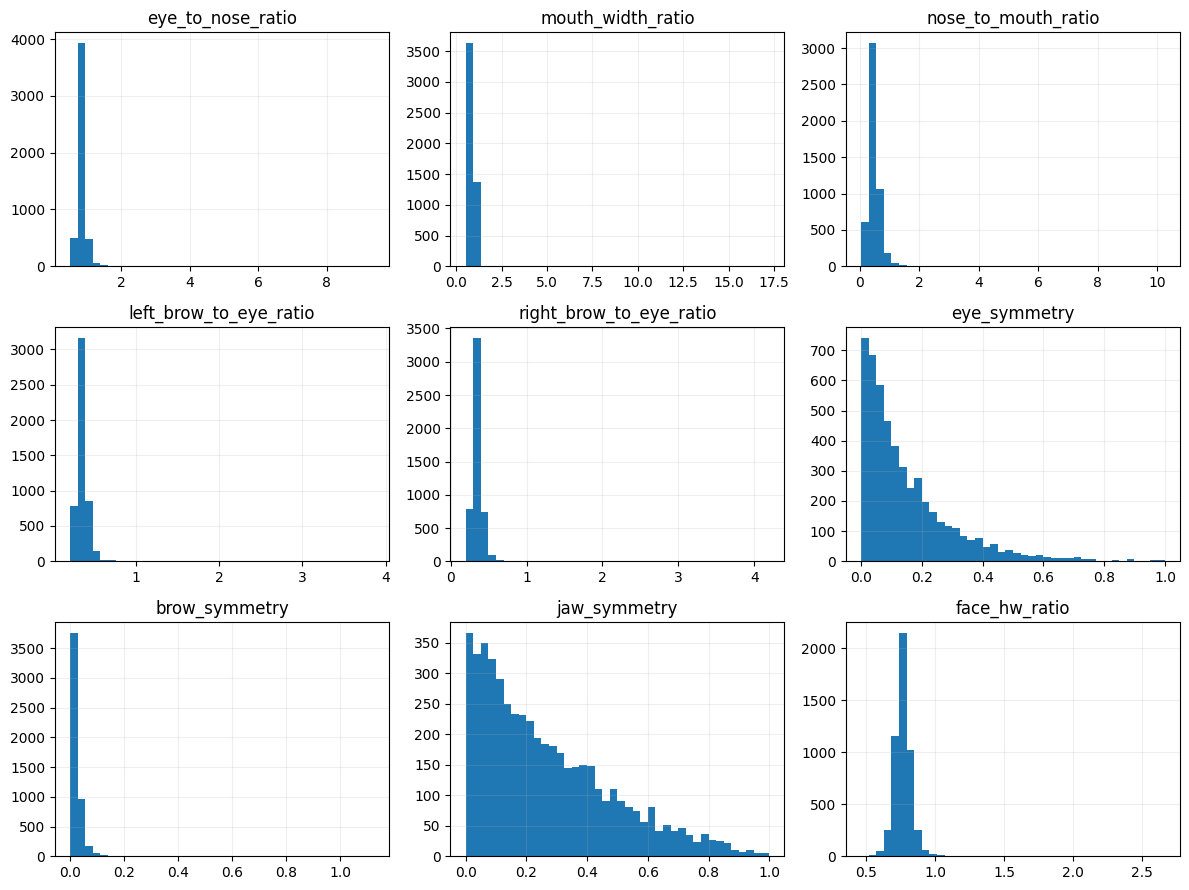

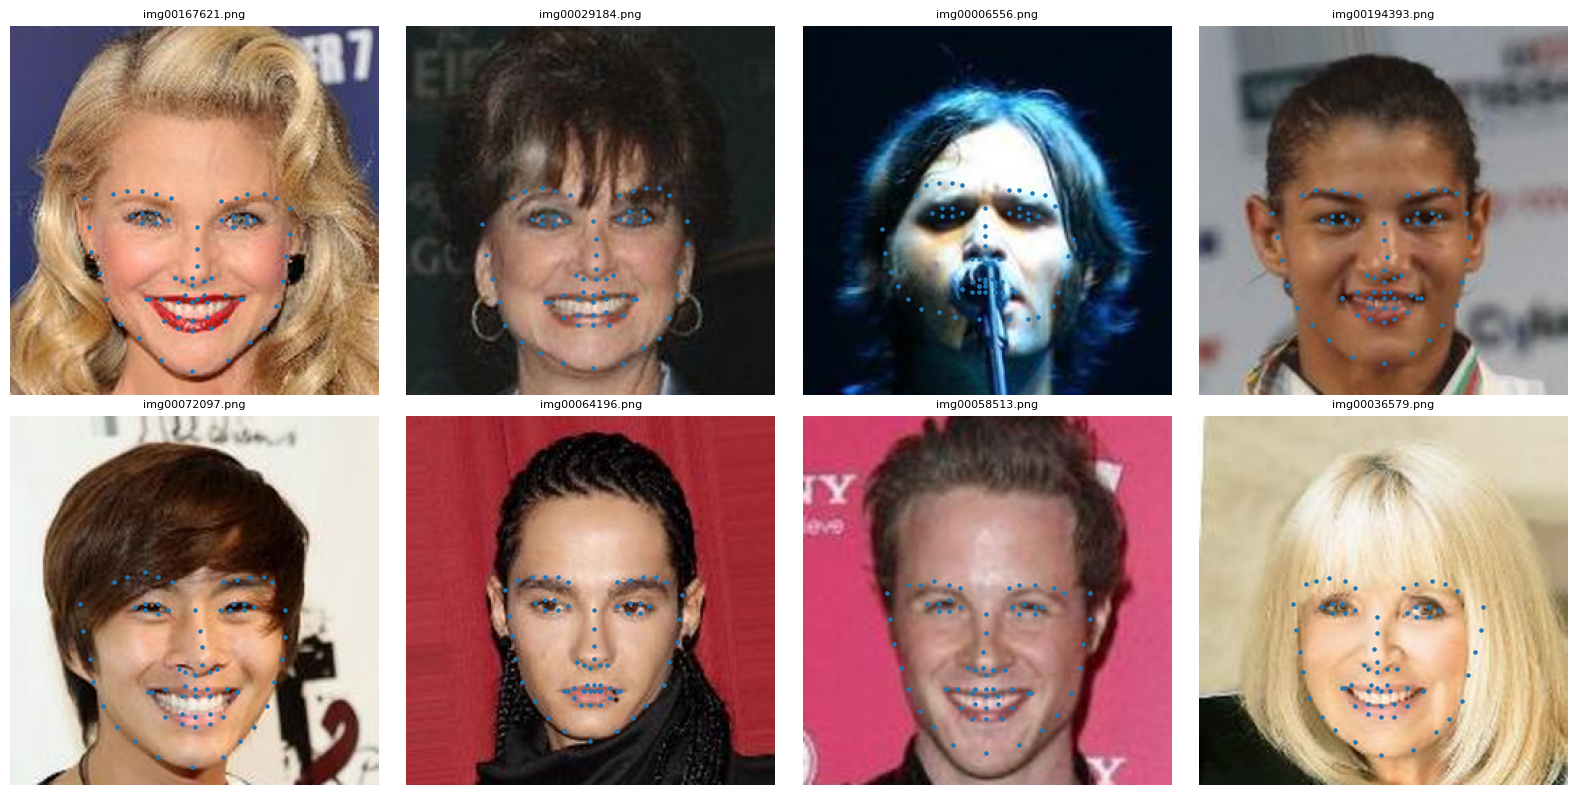

\nNotebook 06 complete.
Next notebook: 07_landmark_regularized_training.ipynb
Use stats file: /data/Sajjan_Singh/gen/gen_scaffold/realistic_face_generation/data/manifests/real_landmark_stats.npz


In [2]:
from pathlib import Path
import os, sys, subprocess, json, zipfile, random, math, io, textwrap
from datetime import datetime

# =========================================================
# INSTALLS
# =========================================================
subprocess.run(
    [sys.executable, "-m", "pip", "install", "-q", "face-alignment", "pillow", "numpy", "pandas", "matplotlib", "tqdm"],
    check=True
)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from tqdm.auto import tqdm

# =========================================================
# SETTINGS
# =========================================================
RANDOM_SEED = 42
SAMPLE_SIZE = 5000          # practical for today; increase later if needed
MAX_PREVIEW = 8
SAVE_FEATURE_CSV = True
PLOT_HISTS = True

# =========================================================
# PATHS
# =========================================================
ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()

dataset_zip = ROOT / "data" / "stylegan3_zip" / "celeba_256x256.zip"
manifests_dir = ROOT / "data" / "manifests"
manifests_dir.mkdir(parents=True, exist_ok=True)

stats_npz = manifests_dir / "real_landmark_stats.npz"
stats_json = manifests_dir / "real_landmark_stats_summary.json"
stats_csv = manifests_dir / "real_landmark_features.csv"

losses_dir = ROOT / "src" / "losses"
losses_dir.mkdir(parents=True, exist_ok=True)
helper_py = losses_dir / "landmark_consistency.py"

# =========================================================
# PRECHECKS
# =========================================================
assert dataset_zip.exists(), f"Missing dataset ZIP: {dataset_zip}"

# =========================================================
# ZIP HELPERS
# =========================================================
IMAGE_EXTS = (".png", ".jpg", ".jpeg", ".webp", ".bmp")

def list_images_in_zip(zip_path: Path):
    with zipfile.ZipFile(zip_path, "r") as zf:
        names = [n for n in zf.namelist() if n.lower().endswith(IMAGE_EXTS)]
    return sorted(names)

def load_image_from_zip(zip_path: Path, inner_name: str):
    with zipfile.ZipFile(zip_path, "r") as zf:
        data = zf.read(inner_name)
    img = Image.open(io.BytesIO(data)).convert("RGB")
    return np.array(img)

# =========================================================
# LANDMARK DETECTOR
# =========================================================
import torch
import face_alignment

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

# face-alignment official API supports 2D/3D landmarks through PyTorch.
fa = face_alignment.FaceAlignment(
    face_alignment.LandmarksType.TWO_D,
    flip_input=False,
    device=device
)

def get_landmarks_np(img_np):
    """
    Tries modern and older face_alignment APIs.
    Returns first face's 68x2 landmarks, or None.
    """
    try:
        preds = fa.get_landmarks_from_image(img_np)
    except Exception:
        try:
            preds = fa.get_landmarks(img_np)
        except Exception:
            preds = None

    if preds is None or len(preds) == 0:
        return None
    lm = np.asarray(preds[0], dtype=np.float32)
    if lm.shape[0] < 68:
        return None
    return lm[:, :2]

# =========================================================
# FEATURE DESIGN
# =========================================================
FEATURE_NAMES = [
    "eye_to_nose_ratio",
    "mouth_width_ratio",
    "nose_to_mouth_ratio",
    "left_brow_to_eye_ratio",
    "right_brow_to_eye_ratio",
    "eye_symmetry",
    "brow_symmetry",
    "jaw_symmetry",
    "face_hw_ratio",
]

def features_from_landmarks(lm):
    """
    lm: (68,2) array
    Returns scale-normalized geometry features.
    """
    lm = np.asarray(lm, dtype=np.float32)

    left_eye = lm[36:42].mean(axis=0)
    right_eye = lm[42:48].mean(axis=0)
    nose = lm[30]
    mouth_l = lm[48]
    mouth_r = lm[54]
    mouth_center = (mouth_l + mouth_r) / 2.0
    jaw_l = lm[0]
    jaw_r = lm[16]
    chin = lm[8]
    brow_l = lm[17:22].mean(axis=0)
    brow_r = lm[22:27].mean(axis=0)
    eye_center = (left_eye + right_eye) / 2.0

    inter_ocular = np.linalg.norm(left_eye - right_eye) + 1e-8
    jaw_width = np.linalg.norm(jaw_l - jaw_r) + 1e-8
    face_height = np.linalg.norm(eye_center - chin) + 1e-8

    eye_to_nose_ratio = (
        (np.linalg.norm(left_eye - nose) + np.linalg.norm(right_eye - nose)) / 2.0
    ) / inter_ocular

    mouth_width_ratio = np.linalg.norm(mouth_l - mouth_r) / inter_ocular
    nose_to_mouth_ratio = np.linalg.norm(nose - mouth_center) / inter_ocular
    left_brow_to_eye_ratio = np.linalg.norm(brow_l - left_eye) / inter_ocular
    right_brow_to_eye_ratio = np.linalg.norm(brow_r - right_eye) / inter_ocular

    eye_symmetry = abs(
        np.linalg.norm(left_eye - nose) - np.linalg.norm(right_eye - nose)
    ) / inter_ocular

    brow_symmetry = abs(
        np.linalg.norm(brow_l - left_eye) - np.linalg.norm(brow_r - right_eye)
    ) / inter_ocular

    jaw_symmetry = abs(
        np.linalg.norm(jaw_l - nose) - np.linalg.norm(jaw_r - nose)
    ) / jaw_width

    face_hw_ratio = face_height / jaw_width

    feats = np.array([
        eye_to_nose_ratio,
        mouth_width_ratio,
        nose_to_mouth_ratio,
        left_brow_to_eye_ratio,
        right_brow_to_eye_ratio,
        eye_symmetry,
        brow_symmetry,
        jaw_symmetry,
        face_hw_ratio,
    ], dtype=np.float32)

    return feats

# =========================================================
# SAMPLE FROM ZIP
# =========================================================
all_imgs = list_images_in_zip(dataset_zip)
assert len(all_imgs) > 0, f"No images found inside {dataset_zip}"

rng = random.Random(RANDOM_SEED)
sample_n = min(SAMPLE_SIZE, len(all_imgs))
sample_imgs = rng.sample(all_imgs, sample_n)

print("Dataset ZIP:", dataset_zip)
print("Total images in ZIP:", len(all_imgs))
print("Sample size:", sample_n)

# =========================================================
# EXTRACT LANDMARK FEATURES
# =========================================================
rows = []
failed = []
preview_examples = []

for inner_name in tqdm(sample_imgs, desc="Computing landmark statistics"):
    try:
        img_np = load_image_from_zip(dataset_zip, inner_name)
        lm = get_landmarks_np(img_np)
        if lm is None:
            failed.append({"image": inner_name, "reason": "no_landmarks"})
            continue

        feats = features_from_landmarks(lm)
        row = {"image": inner_name}
        for k, v in zip(FEATURE_NAMES, feats.tolist()):
            row[k] = float(v)
        rows.append(row)

        if len(preview_examples) < MAX_PREVIEW:
            preview_examples.append((img_np, lm, inner_name))

    except Exception as e:
        failed.append({"image": inner_name, "reason": str(e)})

assert len(rows) > 0, "No landmark features were extracted. Check face_alignment installation/runtime."

df = pd.DataFrame(rows)
feature_matrix = df[FEATURE_NAMES].to_numpy(dtype=np.float32)

mean = feature_matrix.mean(axis=0)
std = feature_matrix.std(axis=0) + 1e-8
cov = np.cov(feature_matrix, rowvar=False)
precision = np.linalg.pinv(cov + np.eye(cov.shape[0], dtype=np.float32) * 1e-6)

# =========================================================
# SAVE STATS
# =========================================================
np.savez(
    stats_npz,
    feature_names=np.array(FEATURE_NAMES, dtype=object),
    mean=mean.astype(np.float32),
    std=std.astype(np.float32),
    cov=cov.astype(np.float32),
    precision=precision.astype(np.float32),
    num_total_in_zip=np.int64(len(all_imgs)),
    num_sampled=np.int64(sample_n),
    num_success=np.int64(len(df)),
    num_failed=np.int64(len(failed)),
)

summary = {
    "time": datetime.now().isoformat(),
    "dataset_zip": str(dataset_zip),
    "num_total_in_zip": int(len(all_imgs)),
    "num_sampled": int(sample_n),
    "num_success": int(len(df)),
    "num_failed": int(len(failed)),
    "feature_names": FEATURE_NAMES,
    "mean": {k: float(v) for k, v in zip(FEATURE_NAMES, mean)},
    "std": {k: float(v) for k, v in zip(FEATURE_NAMES, std)},
    "stats_npz": str(stats_npz),
}
stats_json.write_text(json.dumps(summary, indent=2), encoding="utf-8")

if SAVE_FEATURE_CSV:
    df.to_csv(stats_csv, index=False)

print("Saved stats NPZ :", stats_npz)
print("Saved stats JSON:", stats_json)
if SAVE_FEATURE_CSV:
    print("Saved features CSV:", stats_csv)
print(json.dumps(summary, indent=2))

# =========================================================
# WRITE HELPER MODULE FOR NOTEBOOK 07
# =========================================================
helper_code = f'''
from pathlib import Path
import numpy as np
import torch

FEATURE_NAMES = {FEATURE_NAMES!r}

def features_from_landmarks_numpy(lm):
    lm = np.asarray(lm, dtype=np.float32)

    left_eye = lm[36:42].mean(axis=0)
    right_eye = lm[42:48].mean(axis=0)
    nose = lm[30]
    mouth_l = lm[48]
    mouth_r = lm[54]
    mouth_center = (mouth_l + mouth_r) / 2.0
    jaw_l = lm[0]
    jaw_r = lm[16]
    chin = lm[8]
    brow_l = lm[17:22].mean(axis=0)
    brow_r = lm[22:27].mean(axis=0)
    eye_center = (left_eye + right_eye) / 2.0

    inter_ocular = np.linalg.norm(left_eye - right_eye) + 1e-8
    jaw_width = np.linalg.norm(jaw_l - jaw_r) + 1e-8
    face_height = np.linalg.norm(eye_center - chin) + 1e-8

    eye_to_nose_ratio = ((np.linalg.norm(left_eye - nose) + np.linalg.norm(right_eye - nose)) / 2.0) / inter_ocular
    mouth_width_ratio = np.linalg.norm(mouth_l - mouth_r) / inter_ocular
    nose_to_mouth_ratio = np.linalg.norm(nose - mouth_center) / inter_ocular
    left_brow_to_eye_ratio = np.linalg.norm(brow_l - left_eye) / inter_ocular
    right_brow_to_eye_ratio = np.linalg.norm(brow_r - right_eye) / inter_ocular
    eye_symmetry = abs(np.linalg.norm(left_eye - nose) - np.linalg.norm(right_eye - nose)) / inter_ocular
    brow_symmetry = abs(np.linalg.norm(brow_l - left_eye) - np.linalg.norm(brow_r - right_eye)) / inter_ocular
    jaw_symmetry = abs(np.linalg.norm(jaw_l - nose) - np.linalg.norm(jaw_r - nose)) / jaw_width
    face_hw_ratio = face_height / jaw_width

    return np.array([
        eye_to_nose_ratio,
        mouth_width_ratio,
        nose_to_mouth_ratio,
        left_brow_to_eye_ratio,
        right_brow_to_eye_ratio,
        eye_symmetry,
        brow_symmetry,
        jaw_symmetry,
        face_hw_ratio,
    ], dtype=np.float32)

def load_real_landmark_stats(npz_path):
    d = np.load(npz_path, allow_pickle=True)
    return {{
        "feature_names": list(d["feature_names"]),
        "mean": d["mean"].astype(np.float32),
        "std": d["std"].astype(np.float32),
        "cov": d["cov"].astype(np.float32),
        "precision": d["precision"].astype(np.float32),
    }}

def mahalanobis_landmark_loss_torch(fake_features, real_mean, real_precision):
    """
    fake_features: (B, F) torch tensor
    real_mean: (F,) torch tensor
    real_precision: (F, F) torch tensor
    """
    diffs = fake_features - real_mean.unsqueeze(0)
    d2 = torch.einsum("bf,fg,bg->b", diffs, real_precision, diffs)
    return d2.mean()

def zscore_landmark_loss_torch(fake_features, real_mean, real_std):
    z = (fake_features - real_mean.unsqueeze(0)) / (real_std.unsqueeze(0) + 1e-8)
    return (z ** 2).mean()
'''.strip()

helper_py.write_text(helper_code + "\n", encoding="utf-8")
print("Wrote helper module:", helper_py)

# =========================================================
# PREVIEW
# =========================================================
if PLOT_HISTS:
    n_features = len(FEATURE_NAMES)
    cols = 3
    rows_plot = math.ceil(n_features / cols)
    fig, axes = plt.subplots(rows_plot, cols, figsize=(4 * cols, 3 * rows_plot))
    axes = np.array(axes).reshape(rows_plot, cols)

    for i, fname in enumerate(FEATURE_NAMES):
        ax = axes[i // cols, i % cols]
        ax.hist(df[fname].values, bins=40)
        ax.set_title(fname)
        ax.grid(alpha=0.2)

    for j in range(n_features, rows_plot * cols):
        axes[j // cols, j % cols].axis("off")

    plt.tight_layout()
    plt.show()

# =========================================================
# OPTIONAL VISUAL LANDMARK PREVIEW
# =========================================================
if len(preview_examples) > 0:
    cols = min(4, len(preview_examples))
    rows_plot = math.ceil(len(preview_examples) / cols)
    fig, axes = plt.subplots(rows_plot, cols, figsize=(4 * cols, 4 * rows_plot))
    axes = np.array(axes).reshape(rows_plot, cols)

    k = 0
    for r in range(rows_plot):
        for c in range(cols):
            ax = axes[r, c]
            if k < len(preview_examples):
                img_np, lm, name = preview_examples[k]
                ax.imshow(img_np)
                ax.scatter(lm[:, 0], lm[:, 1], s=5)
                ax.set_title(Path(name).name[:24], fontsize=8)
                ax.axis("off")
            else:
                ax.axis("off")
            k += 1
    plt.tight_layout()
    plt.show()

print("\\nNotebook 06 complete.")
print("Next notebook: 07_landmark_regularized_training.ipynb")
print("Use stats file:", stats_npz)